# Baryquark And Quarkyonic Symmetric Survey

symmetric-matter workflow built from **QMM example JSON files**.

It does four things:

1. runs the symmetric **vdW**, **CS**, **TVM**, and **Clausius** cases from JSON files in `QMM/examples`
2. uses `\Lambda = 200\,\mathrm{MeV}` for **quarkyonic** and `\Lambda = 0` for **baryquark**
3. reconstructs the **baryquark** sound speed from the **raw** energy-density curve, which keeps the sharper peak seen in the paper-style figure
4. builds the additional control curve **vdW excl. volume only**, meaning the same vdW repulsive mapping with the attractive mean field removed in the symmetric quarkyonic/baryquark energy functional

The example JSON files used by this notebook are saved in `QMM/examples`.


In [1]:
from pathlib import Path
import json
import os
import shutil
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
QMM_ROOT = ROOT / 'QMM' if (ROOT / 'QMM').exists() else ROOT
preferred_python = Path('/opt/homebrew/bin/python3.12')
PYTHON = str(preferred_python) if preferred_python.exists() else (shutil.which('python3.12') or sys.executable)

FORCE_RERUN = False
NOTEBOOK_OUTPUT_DIR = QMM_ROOT / 'results' / 'generated' / 'baryquark_quarkyonic_notebook'
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CONTROL_SCRIPT = QMM_ROOT / 'scripts' / 'compute_vdw_excluded_volume_only.py'

print('QMM root:', QMM_ROOT)
print('Python executable for QMM runs:', PYTHON)
print('Notebook output dir:', NOTEBOOK_OUTPUT_DIR)


QMM root: /Users/dajuarez4/Documents/QuarkMatt/QMM
Python executable for QMM runs: /opt/homebrew/bin/python3.12
Notebook output dir: /Users/dajuarez4/Documents/QuarkMatt/QMM/results/generated/baryquark_quarkyonic_notebook


## Example JSON Files

These are the runnable inputs used below. The `vdW excl. volume only` control curve is computed by a small `QMM/scripts` helper because it is a derived comparison case rather than a registered `QMM` model.


In [2]:
EXAMPLE_FILES = {
    'vdw_quarkyonic': QMM_ROOT / 'examples' / 'baryquark_quarkyonic_vdw_quarkyonic.json',
    'vdw_baryquark': QMM_ROOT / 'examples' / 'baryquark_quarkyonic_vdw_baryquark.json',
    'cs_quarkyonic': QMM_ROOT / 'examples' / 'baryquark_quarkyonic_cs_quarkyonic.json',
    'cs_baryquark': QMM_ROOT / 'examples' / 'baryquark_quarkyonic_cs_baryquark.json',
    'tvm_quarkyonic': QMM_ROOT / 'examples' / 'baryquark_quarkyonic_tvm_quarkyonic.json',
    'tvm_baryquark': QMM_ROOT / 'examples' / 'baryquark_quarkyonic_tvm_baryquark.json',
    'clausius_quarkyonic': QMM_ROOT / 'examples' / 'baryquark_quarkyonic_clausius_quarkyonic.json',
    'clausius_baryquark': QMM_ROOT / 'examples' / 'baryquark_quarkyonic_clausius_baryquark.json',
}

for name, path in EXAMPLE_FILES.items():
    print(name, '->', path.relative_to(QMM_ROOT))


vdw_quarkyonic -> examples/baryquark_quarkyonic_vdw_quarkyonic.json
vdw_baryquark -> examples/baryquark_quarkyonic_vdw_baryquark.json
cs_quarkyonic -> examples/baryquark_quarkyonic_cs_quarkyonic.json
cs_baryquark -> examples/baryquark_quarkyonic_cs_baryquark.json
tvm_quarkyonic -> examples/baryquark_quarkyonic_tvm_quarkyonic.json
tvm_baryquark -> examples/baryquark_quarkyonic_tvm_baryquark.json
clausius_quarkyonic -> examples/baryquark_quarkyonic_clausius_quarkyonic.json
clausius_baryquark -> examples/baryquark_quarkyonic_clausius_baryquark.json


In [3]:
def read_example_json(path):
    return json.loads(Path(path).read_text())


def example_output_paths(json_path):
    payload = read_example_json(json_path)
    out_dir = QMM_ROOT / payload['output']['directory']
    run_name = payload['run_name']
    summary_path = out_dir / f'{run_name}_summary.json'
    curve_path = out_dir / f'{run_name}_symmetric_quarkyonic_curve.csv'
    return payload, out_dir, summary_path, curve_path


def run_example(json_path, force=False):
    payload, out_dir, summary_path, curve_path = example_output_paths(json_path)

    needs_run = force or (not summary_path.exists()) or (not curve_path.exists())
    if not needs_run and curve_path.exists():
        try:
            existing = pd.read_csv(curve_path, nrows=3)
            if 'eps_raw' not in existing.columns:
                needs_run = True
        except Exception:
            needs_run = True

    if needs_run:
        env = dict(os.environ)
        env['PYTHONPATH'] = 'src'
        result = subprocess.run(
            [PYTHON, '-m', 'qmm', str(json_path)],
            cwd=QMM_ROOT,
            env=env,
            capture_output=True,
            text=True,
            check=True,
        )
        if result.stdout.strip():
            print(result.stdout.strip())

    summary = json.loads(summary_path.read_text())
    curve = pd.read_csv(curve_path)
    return payload, summary, curve


def direct_vs2_from_raw(curve_df):
    n = curve_df['n'].to_numpy(dtype=float)
    eps_raw = curve_df['eps_raw'].to_numpy(dtype=float)
    mu_b = np.gradient(eps_raw, n, edge_order=2)
    mu_bb = np.gradient(mu_b, n, edge_order=2)
    with np.errstate(divide='ignore', invalid='ignore'):
        vs2 = n * mu_bb / mu_b
    return vs2


def plot_vs2_values(curve_df, momentum_mode):
    if momentum_mode == 'baryquark' and 'eps_raw' in curve_df.columns:
        return direct_vs2_from_raw(curve_df)
    return curve_df['vs2'].to_numpy(dtype=float, copy=True)


def ensure_vdw_excluded_volume_only(json_path, force=False):
    payload = read_example_json(json_path)
    mode = payload['quarkyonic']['momentum_mode']
    curve_path = NOTEBOOK_OUTPUT_DIR / f'vdw_excluded_volume_only_{mode}.csv'
    summary_path = NOTEBOOK_OUTPUT_DIR / f'vdw_excluded_volume_only_{mode}.json'

    needs_run = force or (not curve_path.exists()) or (not summary_path.exists())
    if needs_run:
        env = dict(os.environ)
        env['PYTHONPATH'] = 'src'
        result = subprocess.run(
            [PYTHON, str(CONTROL_SCRIPT), str(json_path), str(curve_path), str(summary_path)],
            cwd=QMM_ROOT,
            env=env,
            capture_output=True,
            text=True,
            check=True,
        )
        if result.stdout.strip():
            print(result.stdout.strip())

    summary = json.loads(summary_path.read_text())
    curve = pd.read_csv(curve_path)
    return summary, curve


## Run The Symmetric JSON Examples

In [4]:
example_results = {}
for name, path in EXAMPLE_FILES.items():
    print(f'Loading {name} ...')
    payload, summary, curve = run_example(path, force=FORCE_RERUN)
    mode = payload['quarkyonic']['momentum_mode']
    curve = curve.sort_values('n_over_n0').copy()
    curve['vs2_plot'] = plot_vs2_values(curve, mode)
    example_results[name] = {
        'payload': payload,
        'summary': summary,
        'curve': curve,
        'mode': mode,
        'model': payload['model']['name'],
        'lambda_mev': payload['quarkyonic']['lambda_momentum_mev'],
    }

summary_rows = []
for name, block in example_results.items():
    sym = block['summary']['symmetric_quarkyonic']
    curve = block['curve']
    finite_vs2 = curve['vs2_plot'].replace([np.inf, -np.inf], np.nan).dropna()
    summary_rows.append({
        'example': name,
        'model': block['model'],
        'mode': block['mode'],
        'lambda_mev': block['lambda_mev'],
        'a_MeV_fm3': sym['a'],
        'b_fm3': sym['b'],
        'K0_MeV': sym['K0'],
        'parameter_value': sym.get('parameter_value'),
        'n_tr_over_n0_smoothed': sym['n_tr_over_n0'],
        'vs2_max_plot': finite_vs2.max() if len(finite_vs2) else np.nan,
    })

pd.DataFrame(summary_rows)


Loading vdw_quarkyonic ...
Loading vdw_baryquark ...
Loading cs_quarkyonic ...
Loading cs_baryquark ...
Loading tvm_quarkyonic ...
Loading tvm_baryquark ...
Loading clausius_quarkyonic ...
Loading clausius_baryquark ...


,example,model,mode,lambda_mev,a_MeV_fm3,b_fm3,K0_MeV,parameter_value,n_tr_over_n0_smoothed,vs2_max_plot
0,vdw_quarkyonic,vdw,quarkyonic,200.0,328.923321,3.414020,762.538953,NaN,1.484019,0.906199
1,vdw_baryquark,vdw,baryquark,0.0,328.923321,3.414020,762.538953,NaN,1.347033,0.891919
2,cs_quarkyonic,cs,quarkyonic,200.0,347.017219,4.426715,601.449391,NaN,1.757992,0.701243
3,cs_baryquark,cs,baryquark,0.0,347.017219,4.426715,601.449391,NaN,1.598174,0.832711
4,tvm_quarkyonic,tvm,quarkyonic,200.0,349.009326,4.280134,564.221282,NaN,1.894978,0.647155
5,tvm_baryquark,tvm,baryquark,0.0,349.009326,4.280134,564.221282,NaN,1.735160,0.796684
6,clausius_quarkyonic,clausius,quarkyonic,200.0,454.412697,1.936450,280.000000,4.114108,2.579909,1.094192
7,clausius_baryquark,clausius,baryquark,0.0,454.412697,1.936450,280.000000,4.114108,2.100457,0.545978


## Build The `vdW excl. volume only` Control Curve

This uses the **same vdW repulsive mapping** and the **same vdW ground-state `b`**, but the attractive mean-field contribution is removed from the symmetric quarkyonic/baryquark energy. This reproduces the comparison line shown as `vdW excl. volume only` in the paper-style figure.


In [5]:
vdw_ev_only = {
    'quarkyonic': ensure_vdw_excluded_volume_only(EXAMPLE_FILES['vdw_quarkyonic'], force=FORCE_RERUN),
    'baryquark': ensure_vdw_excluded_volume_only(EXAMPLE_FILES['vdw_baryquark'], force=FORCE_RERUN),
}

for mode, (summary, curve) in vdw_ev_only.items():
    print(mode, summary)


quarkyonic {'source_example': '/Users/dajuarez4/Documents/QuarkMatt/QMM/examples/baryquark_quarkyonic_vdw_quarkyonic.json', 'model': 'vdw_excluded_volume_only', 'momentum_mode': 'quarkyonic', 'lambda_mev': 200.0, 'a_MeV_fm3': 328.9233214199405, 'b_fm3': 3.4140201144371347, 'K0_MeV': 762.5389525731663, 'vs2_plot_max': 0.5043375347880308, 'n_tr_over_n0_plot': 1.4383568767123287}
baryquark {'source_example': '/Users/dajuarez4/Documents/QuarkMatt/QMM/examples/baryquark_quarkyonic_vdw_baryquark.json', 'model': 'vdw_excluded_volume_only', 'momentum_mode': 'baryquark', 'lambda_mev': 0.0, 'a_MeV_fm3': 328.9233214199405, 'b_fm3': 3.4140201144371347, 'K0_MeV': 762.5389525731663, 'vs2_plot_max': 0.28154324241122936, 'n_tr_over_n0_plot': 2.00913301826484}


## Paper-Style Symmetric Comparison

This reproduces the optimized comparison with

- **vdW** mean field `U(n_N) = -a n_N`
- **Carnahan-Starling**
- **TVM**
- **vdW excl. volume only**

The top row uses **quarkyonic** with `\Lambda = 200\,\mathrm{MeV}`.
The bottom row uses **baryquark** with `\Lambda = 0`.


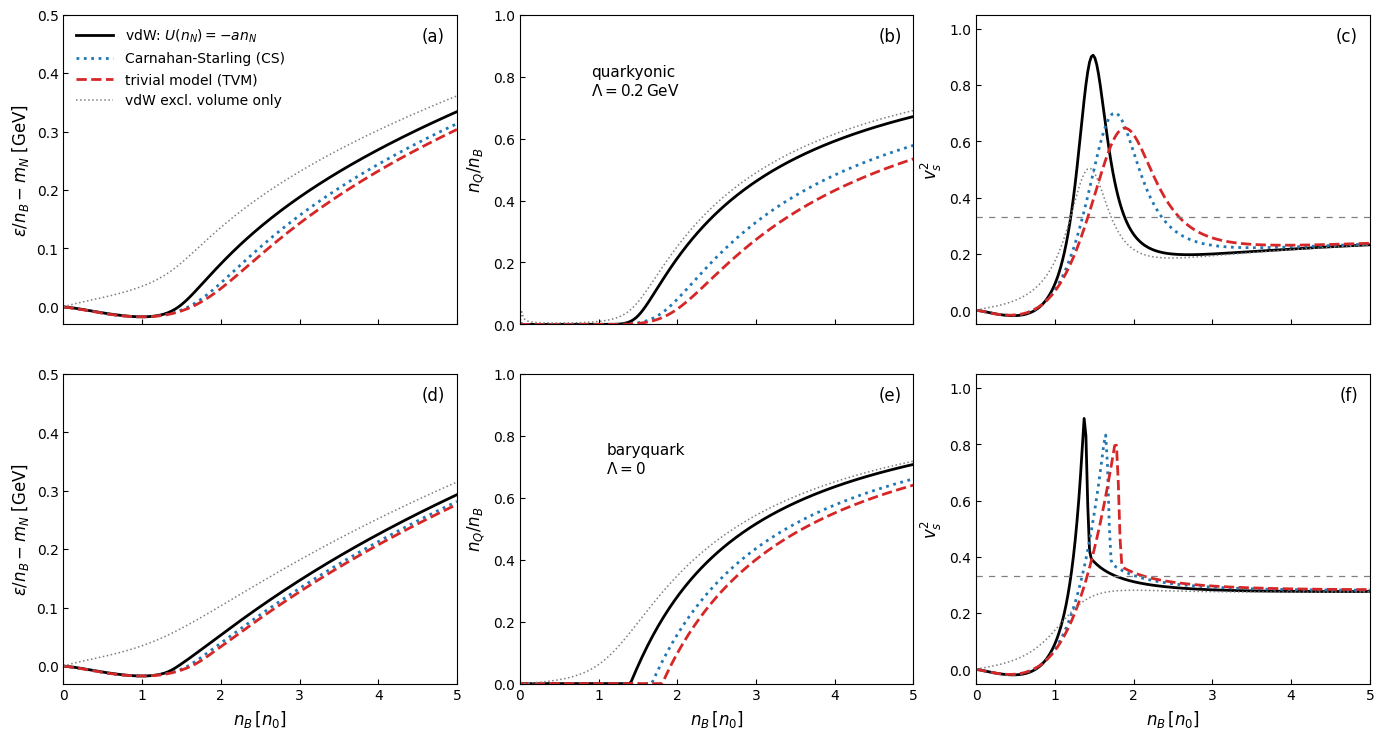

Saved: results/generated/baryquark_quarkyonic_notebook/baryquark_quarkyonic_paper_style.png
Saved: results/generated/baryquark_quarkyonic_notebook/baryquark_quarkyonic_paper_style.pdf


In [6]:
PAPER_STYLES = {
    'vdw': {'label': r'vdW: $U(n_N)=-a n_N$', 'color': 'black', 'linestyle': '-', 'linewidth': 2.0},
    'cs': {'label': 'Carnahan-Starling (CS)', 'color': '#1f77b4', 'linestyle': ':', 'linewidth': 2.0},
    'tvm': {'label': 'trivial model (TVM)', 'color': '#d62728', 'linestyle': '--', 'linewidth': 2.0},
    'vdw_excluded_volume_only': {'label': 'vdW excl. volume only', 'color': '#7f7f7f', 'linestyle': ':', 'linewidth': 1.1},
}

paper_curves = {
    'quarkyonic': {
        'vdw': example_results['vdw_quarkyonic']['curve'],
        'cs': example_results['cs_quarkyonic']['curve'],
        'tvm': example_results['tvm_quarkyonic']['curve'],
        'vdw_excluded_volume_only': vdw_ev_only['quarkyonic'][1],
    },
    'baryquark': {
        'vdw': example_results['vdw_baryquark']['curve'],
        'cs': example_results['cs_baryquark']['curve'],
        'tvm': example_results['tvm_baryquark']['curve'],
        'vdw_excluded_volume_only': vdw_ev_only['baryquark'][1],
    },
}

fig, axes = plt.subplots(2, 3, figsize=(14.2, 7.6), sharex=True)

for row_index, mode in enumerate(['quarkyonic', 'baryquark']):
    ax_e = axes[row_index, 0]
    ax_fq = axes[row_index, 1]
    ax_vs = axes[row_index, 2]

    for key in ['vdw', 'cs', 'tvm', 'vdw_excluded_volume_only']:
        df = paper_curves[mode][key].sort_values('n_over_n0').copy()
        style = PAPER_STYLES[key]
        x = df['n_over_n0'].to_numpy(dtype=float, copy=True)
        energy_plot = (df['eps'] / df['n'] / 1000.0 - 0.939).to_numpy(dtype=float, copy=True)
        fq_plot = df['quark_fraction'].to_numpy(dtype=float, copy=True)
        vs_plot = df['vs2_plot'].to_numpy(dtype=float, copy=True) if 'vs2_plot' in df.columns else np.array(plot_vs2_values(df, mode), dtype=float, copy=True)

        if len(x) and x[0] < 1.0e-3:
            x[0] = 0.0
            energy_plot[0] = 0.0
            fq_plot[0] = 0.0
            vs_plot[0] = 0.0

        ax_e.plot(x, energy_plot, color=style['color'], ls=style['linestyle'], lw=style['linewidth'], label=style['label'])
        ax_fq.plot(x, fq_plot, color=style['color'], ls=style['linestyle'], lw=style['linewidth'], label=style['label'])
        ax_vs.plot(x, vs_plot, color=style['color'], ls=style['linestyle'], lw=style['linewidth'], label=style['label'])

    for ax in (ax_e, ax_fq, ax_vs):
        ax.set_xlim(0.0, 5.0)
        ax.set_xticks([0, 1, 2, 3, 4, 5])
        ax.tick_params(axis='both', labelsize=10, direction='in')

    ax_e.set_ylim(-0.03, 0.5)
    ax_fq.set_ylim(0.0, 1.0)
    ax_vs.set_ylim(-0.05, 1.05)
    ax_vs.axhline(1.0 / 3.0, color='gray', ls=(0, (5, 5)), lw=0.9)

    if row_index == 0:
        ax_e.text(0.97, 0.96, '(a)', transform=ax_e.transAxes, ha='right', va='top', fontsize=12)
        ax_fq.text(0.97, 0.96, '(b)', transform=ax_fq.transAxes, ha='right', va='top', fontsize=12)
        ax_vs.text(0.97, 0.96, '(c)', transform=ax_vs.transAxes, ha='right', va='top', fontsize=12)
        ax_fq.text(0.18, 0.74, 'quarkyonic\n$\Lambda = 0.2\,\mathrm{GeV}$', transform=ax_fq.transAxes, fontsize=11)
    else:
        ax_e.text(0.97, 0.96, '(d)', transform=ax_e.transAxes, ha='right', va='top', fontsize=12)
        ax_fq.text(0.97, 0.96, '(e)', transform=ax_fq.transAxes, ha='right', va='top', fontsize=12)
        ax_vs.text(0.97, 0.96, '(f)', transform=ax_vs.transAxes, ha='right', va='top', fontsize=12)
        ax_fq.text(0.22, 0.68, 'baryquark\n$\Lambda = 0$', transform=ax_fq.transAxes, fontsize=11)

axes[0, 0].legend(loc='upper left', fontsize=10, frameon=False, handlelength=2.7)
for row in axes:
    row[0].set_ylabel(r'$\epsilon/n_B - m_N$ [GeV]', fontsize=12)
    row[1].set_ylabel(r'$n_Q/n_B$', fontsize=12)
    row[2].set_ylabel(r'$v_s^2$', fontsize=12)
for ax in axes[1, :]:
    ax.set_xlabel(r'$n_B\,[n_0]$', fontsize=12)

fig.subplots_adjust(left=0.07, right=0.99, bottom=0.10, top=0.98, wspace=0.16, hspace=0.16)

paper_png = NOTEBOOK_OUTPUT_DIR / 'baryquark_quarkyonic_paper_style.png'
paper_pdf = NOTEBOOK_OUTPUT_DIR / 'baryquark_quarkyonic_paper_style.pdf'
fig.savefig(paper_png, dpi=240)
fig.savefig(paper_pdf)
plt.show()

print('Saved:', paper_png.relative_to(QMM_ROOT))
print('Saved:', paper_pdf.relative_to(QMM_ROOT))


## Clausius Symmetric Comparison

Clausius is shown separately because it is not part of the original four-curve paper panel, but you asked to include the symmetric Clausius result in the same cleaned notebook.


## Clausius Symmetric Comparison

Clausius is shown separately because it is not part of the original four-curve paper panel, but you asked to include the symmetric Clausius result in the same cleaned notebook.


## Clausius Symmetric Comparison

Clausius is shown separately because it is not part of the original four-curve paper panel, but you asked to include the symmetric Clausius result in the same cleaned notebook.


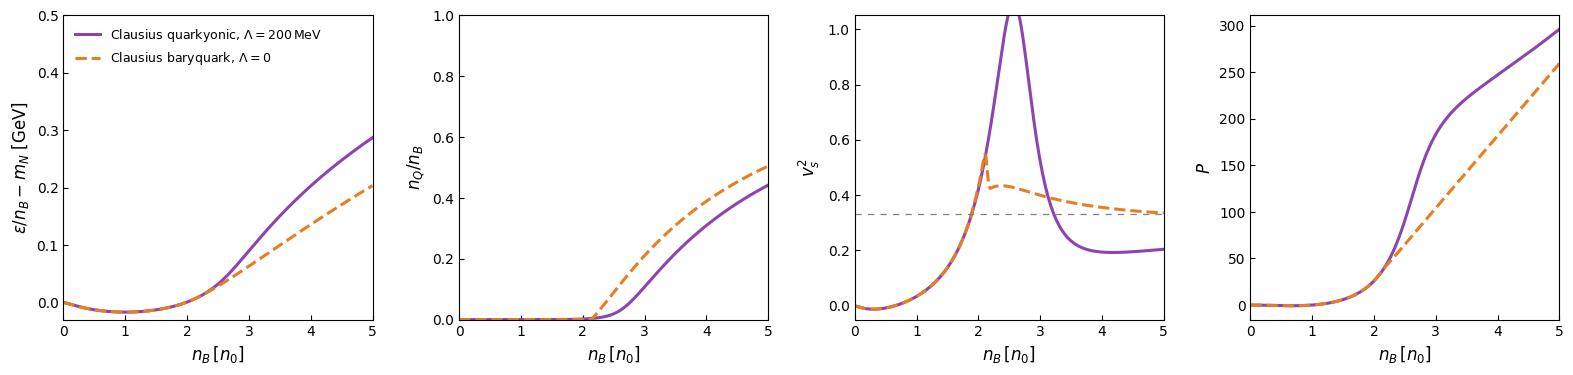

Saved: results/generated/baryquark_quarkyonic_notebook/clausius_symmetric_quarkyonic_baryquark.png
Saved: results/generated/baryquark_quarkyonic_notebook/clausius_symmetric_quarkyonic_baryquark.pdf


,mode,lambda_mev,c_value,K0_MeV,n_tr_over_n0_smoothed,vs2_max_plot
0,quarkyonic,200.0,4.114108,280.0,2.579909,1.094192
1,baryquark,0.0,4.114108,280.0,2.100457,0.545978


In [7]:
clausius_quark = example_results['clausius_quarkyonic']['curve'].sort_values('n_over_n0').copy()
clausius_bary = example_results['clausius_baryquark']['curve'].sort_values('n_over_n0').copy()

fig, axes = plt.subplots(1, 4, figsize=(16.0, 3.9))
clausius_styles = {
    'quarkyonic': {'label': r'Clausius quarkyonic, $\Lambda=200\,\mathrm{MeV}$', 'color': '#8e44ad', 'linestyle': '-', 'linewidth': 2.2},
    'baryquark': {'label': r'Clausius baryquark, $\Lambda=0$', 'color': '#e67e22', 'linestyle': '--', 'linewidth': 2.2},
}

for mode, df in [('quarkyonic', clausius_quark), ('baryquark', clausius_bary)]:
    style = clausius_styles[mode]
    x = df['n_over_n0'].to_numpy(dtype=float, copy=True)
    energy_plot = (df['eps'] / df['n'] / 1000.0 - 0.939).to_numpy(dtype=float, copy=True)
    fq_plot = df['quark_fraction'].to_numpy(dtype=float, copy=True)
    vs_plot = df['vs2_plot'].to_numpy(dtype=float, copy=True)
    pressure_plot = df['pressure'].to_numpy(dtype=float, copy=True)

    if len(x) and x[0] < 1.0e-3:
        x[0] = 0.0
        energy_plot[0] = 0.0
        fq_plot[0] = 0.0
        vs_plot[0] = 0.0
        pressure_plot[0] = 0.0

    axes[0].plot(x, energy_plot, color=style['color'], ls=style['linestyle'], lw=style['linewidth'], label=style['label'])
    axes[1].plot(x, fq_plot, color=style['color'], ls=style['linestyle'], lw=style['linewidth'], label=style['label'])
    axes[2].plot(x, vs_plot, color=style['color'], ls=style['linestyle'], lw=style['linewidth'], label=style['label'])
    axes[3].plot(x, pressure_plot, color=style['color'], ls=style['linestyle'], lw=style['linewidth'], label=style['label'])

axes[2].axhline(1.0 / 3.0, color='gray', ls=(0, (5, 5)), lw=0.9)
axes[0].set_ylabel(r'$\epsilon/n_B - m_N$ [GeV]', fontsize=12)
axes[1].set_ylabel(r'$n_Q/n_B$', fontsize=12)
axes[2].set_ylabel(r'$v_s^2$', fontsize=12)
axes[3].set_ylabel(r'$P$', fontsize=12)

for ax in axes:
    ax.set_xlim(0.0, 5.0)
    ax.set_xticks([0, 1, 2, 3, 4, 5])
    ax.tick_params(axis='both', labelsize=10, direction='in')
    ax.set_xlabel(r'$n_B\,[n_0]$', fontsize=12)

axes[0].set_ylim(-0.03, 0.5)
axes[1].set_ylim(0.0, 1.0)
axes[2].set_ylim(-0.05, 1.05)
axes[0].legend(loc='upper left', fontsize=9, frameon=False)

fig.subplots_adjust(left=0.06, right=0.995, bottom=0.18, top=0.96, wspace=0.28)
clausius_png = NOTEBOOK_OUTPUT_DIR / 'clausius_symmetric_quarkyonic_baryquark.png'
clausius_pdf = NOTEBOOK_OUTPUT_DIR / 'clausius_symmetric_quarkyonic_baryquark.pdf'
fig.savefig(clausius_png, dpi=240)
fig.savefig(clausius_pdf)
plt.show()

clausius_summary = pd.DataFrame([
    {
        'mode': 'quarkyonic',
        'lambda_mev': example_results['clausius_quarkyonic']['lambda_mev'],
        'c_value': example_results['clausius_quarkyonic']['summary']['symmetric_quarkyonic']['parameter_value'],
        'K0_MeV': example_results['clausius_quarkyonic']['summary']['symmetric_quarkyonic']['K0'],
        'n_tr_over_n0_smoothed': example_results['clausius_quarkyonic']['summary']['symmetric_quarkyonic']['n_tr_over_n0'],
        'vs2_max_plot': float(clausius_quark['vs2_plot'].replace([np.inf, -np.inf], np.nan).dropna().max()),
    },
    {
        'mode': 'baryquark',
        'lambda_mev': example_results['clausius_baryquark']['lambda_mev'],
        'c_value': example_results['clausius_baryquark']['summary']['symmetric_quarkyonic']['parameter_value'],
        'K0_MeV': example_results['clausius_baryquark']['summary']['symmetric_quarkyonic']['K0'],
        'n_tr_over_n0_smoothed': example_results['clausius_baryquark']['summary']['symmetric_quarkyonic']['n_tr_over_n0'],
        'vs2_max_plot': float(clausius_bary['vs2_plot'].replace([np.inf, -np.inf], np.nan).dropna().max()),
    },
])

print('Saved:', clausius_png.relative_to(QMM_ROOT))
print('Saved:', clausius_pdf.relative_to(QMM_ROOT))
clausius_summary
